# Generalized strength-emulator animation notebook

This notebook replaces the older two-script workflow for animating strength evolution and eigenvalue evolution. It is designed for the generalized **strength + alphaD emulator** built around `helper_gpt.py` and `main_gpt.py`.

It supports:
- an arbitrary number of input parameters
- choosing **one parameter to sweep**
- holding the other parameters fixed, or selecting a nearby slice from the dataset
- projecting the dataset onto **two chosen parameters** for the grid panel
- optionally showing the eigenvalue-evolution panel

For datasets with more than two parameters, the grid panel is a **2D projection**, not the full parameter space.


In [1]:
import json
import os
from pathlib import Path

import numpy as np
import tensorflow as tf

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LogNorm

import helper_gpt

plt.rcParams.update({"font.size": 14})
matplotlib.rcParams["animation.embed_limit"] = 200


## Configuration

In [ ]:
# --- Paths ---
RUN_DIR = Path("runs_em1")              # directory created by main_gpt.py
BEST_PARAMS_FILE = RUN_DIR / "best_params_global.txt"
RUN_SUMMARY_FILE = RUN_DIR / "run_summary.json"

# --- Dataset locations ---
STRENGTH_DIR = "../dipoles_data_all/total_strength/"
ALPHAD_DIR = "../dipoles_data_all/total_alphaD/"

# Optional: leave as None to use defaults from run_summary / helper_gpt
STRENGTH_REGEX = None
ALPHAD_REGEX = None
FILTER_RANGES = None                    # e.g. {"p1": [0.4, 1.8], "p2": [1.5, 4.0]}
CENTRAL_POINT = None                    # e.g. [1.0, 2.5, ...]

# --- Animation controls ---
SWEEP_PARAM = None                      # e.g. "p1"; None -> first parameter
FIXED_VALUES = {}                       # e.g. {"p2": 2.0, "p3": 1.1}
SHOW_EIGENVALUE_PANEL = True
FPS = 1.5
INTERVAL_MS = 700

# --- Plot projection (used for the parameter-space panel) ---
X_PARAM = None                          # e.g. "p1"; None -> first parameter
Y_PARAM = None                          # e.g. "p2"; None -> second parameter if available
MATCH_TOL = 1e-6                        # tolerance for slicing non-swept parameters
ALLOWED_SLICE_DRIFT = None              # e.g. 0.05; None keeps nearest available points

# --- Strength-axis limits (set to None for auto) ---
ENERGY_XLIM = (0.0, 40.0)
STRENGTH_YLIM = None

# --- Output ---
OUTPUT_MP4 = "animate_strength_evolution_generalized.mp4"


## Load run metadata and dataset

In [9]:
with open(RUN_SUMMARY_FILE, "r") as f:
    run_summary = json.load(f)

args = run_summary["args"]
config_dict = run_summary["config"]

strength_regex = STRENGTH_REGEX or args.get("strength_regex") or r"strength_(?P<p2>[0-9.]+)_(?P<p1>[0-9.]+)\.out"
alphaD_regex = ALPHAD_REGEX or args.get("alphaD_regex")
filter_ranges = FILTER_RANGES if FILTER_RANGES is not None else args.get("filter_ranges")
central_point = CENTRAL_POINT if CENTRAL_POINT is not None else args.get("central_point")

dataset = helper_gpt.load_dataset(
    strength_dir=STRENGTH_DIR,
    alphaD_dir=ALPHAD_DIR,
    strength_regex=strength_regex,
    alphaD_regex=alphaD_regex,
    filter_ranges=filter_ranges,
    central_point=central_point,
)

params = np.loadtxt(BEST_PARAMS_FILE).astype(np.float32)
config = helper_gpt.AnsatzConfig(
    n=int(config_dict["n"]),
    n_params=int(config_dict["n_params"]),
    ansatz=config_dict["ansatz"],
    width_model=config_dict["width_model"],
    use_vector_terms=bool(config_dict["use_vector_terms"]),
)

param_names = list(dataset.param_names)
param_to_idx = {name: i for i, name in enumerate(param_names)}

if SWEEP_PARAM is None:
    SWEEP_PARAM = param_names[0]

if X_PARAM is None:
    X_PARAM = param_names[0]

if Y_PARAM is None:
    Y_PARAM = param_names[1] if len(param_names) > 1 else param_names[0]

retain = float(args["retain"])

print("Parameter names:", param_names)
print("Central point:", dataset.central_point)
print("Sweep parameter:", SWEEP_PARAM)
print("Projection axes:", X_PARAM, Y_PARAM)
print("Number of samples:", len(dataset.strengths))


Parameter names: ['p1', 'p2']
Central point: [1.1  2.75]
Sweep parameter: p1
Projection axes: p1 p2
Number of samples: 225


## Helper functions

In [10]:
def _retain_center_block(eigenvalues, eigenvectors, retain):
    n_i = int(eigenvalues.shape[0])
    k_keep = int(round(retain * n_i))
    k_keep = max(1, min(k_keep, n_i))
    left = (n_i - k_keep) // 2
    right = left + k_keep
    return eigenvalues[left:right], eigenvectors[:, left:right], left, right

def evaluate_strength_emulator_point(params_np, config, point, omega_grid, central_point, retain):
    params_tf = tf.convert_to_tensor(params_np, dtype=tf.float32)
    point_tf = tf.convert_to_tensor(np.asarray(point, dtype=np.float32)[None, :], dtype=tf.float32)
    central_tf = tf.convert_to_tensor(np.asarray(central_point, dtype=np.float32), dtype=tf.float32)

    M_batch, v_batch, eta_batch, _ = helper_gpt.build_model_matrices_and_vectors(
        params=params_tf,
        config=config,
        param_values=point_tf,
        central_point=central_tf,
    )

    eigvals_full, eigvecs_full = tf.linalg.eigh(M_batch[0])
    eigvals_keep, eigvecs_keep, left, right = _retain_center_block(eigvals_full, eigvecs_full, retain)

    proj = tf.linalg.matvec(tf.transpose(eigvecs_keep), v_batch[0])
    B_keep = tf.square(proj)
    mask = tf.cast(eigvals_keep > 1.0, tf.float32)
    B_masked = B_keep * mask

    lor = helper_gpt.give_me_Lorentzian(
        omega_grid,
        eigvals_keep,
        B_masked,
        eta_batch[0] / 2.0,
    )
    alphaD_pred = helper_gpt.calculate_alphaD(eigvals_keep, B_keep)

    return {
        "eigvals_full": eigvals_full.numpy(),
        "eigvals_keep": eigvals_keep.numpy(),
        "B_keep": B_keep.numpy(),
        "B_masked": B_masked.numpy(),
        "eta": float(eta_batch[0].numpy()),
        "strength_pred": lor.numpy(),
        "alphaD_pred": float(alphaD_pred.numpy()),
        "keep_left": left,
        "keep_right": right,
    }

def relative_alphaD_error(pred, true):
    return np.abs(pred - true) / np.maximum(np.abs(true), 1e-12)

def choose_slice_points(param_values, param_names, sweep_param, fixed_values, tol=MATCH_TOL):
    values = np.asarray(param_values, dtype=float)
    sweep_idx = param_names.index(sweep_param)

    fixed = {}
    for name in param_names:
        if name == sweep_param:
            continue
        if name in fixed_values:
            fixed[name] = float(fixed_values[name])
        else:
            fixed[name] = float(dataset.central_point[param_names.index(name)])

    distances = np.zeros(len(values), dtype=float)
    exact_mask = np.ones(len(values), dtype=bool)

    for name, target in fixed.items():
        idx = param_names.index(name)
        delta = np.abs(values[:, idx] - target)
        distances += delta**2
        exact_mask &= delta <= tol

    if np.any(exact_mask):
        chosen = np.where(exact_mask)[0]
    else:
        if ALLOWED_SLICE_DRIFT is not None:
            chosen = np.where(np.sqrt(distances) <= ALLOWED_SLICE_DRIFT)[0]
            if len(chosen) == 0:
                chosen = np.argsort(distances)[:max(3, min(12, len(values)))]
        else:
            # nearest available path in the dataset
            chosen = np.argsort(distances)[:max(3, min(12, len(values)))]

    chosen = sorted(chosen, key=lambda i: values[i, sweep_idx])
    return chosen, fixed


## Precompute emulator outputs

In [11]:
omega_ref = dataset.strengths[0][:, 0].astype(np.float32)

pred_cache = []
alphaD_pred_all = np.zeros(len(dataset.strengths), dtype=float)

for i, point in enumerate(dataset.param_values):
    result = evaluate_strength_emulator_point(
        params_np=params,
        config=config,
        point=point,
        omega_grid=omega_ref,
        central_point=dataset.central_point,
        retain=retain,
    )
    pred_cache.append(result)
    alphaD_pred_all[i] = result["alphaD_pred"]

alphaD_err_all = relative_alphaD_error(alphaD_pred_all, dataset.alphaD_values)

slice_indices, used_fixed = choose_slice_points(
    param_values=dataset.param_values,
    param_names=param_names,
    sweep_param=SWEEP_PARAM,
    fixed_values=FIXED_VALUES,
)

slice_points = dataset.param_values[slice_indices]
print("Slice uses", len(slice_indices), "frames")
print("Fixed values used:", used_fixed)


Slice uses 15 frames
Fixed values used: {'p2': 2.75}


## Quick diagnostics

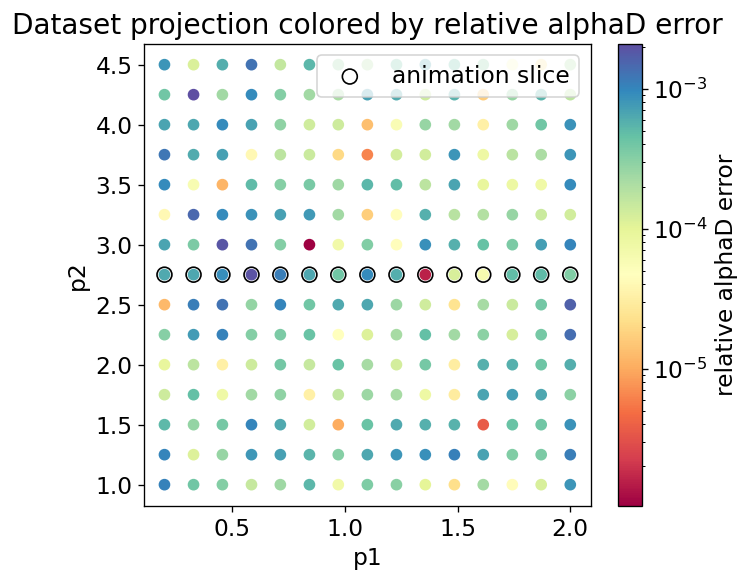

In [12]:
proj_x = dataset.param_values[:, param_to_idx[X_PARAM]]
proj_y = dataset.param_values[:, param_to_idx[Y_PARAM]]

fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
sc = ax.scatter(proj_x, proj_y, c=alphaD_err_all, cmap="Spectral", norm=LogNorm())
ax.scatter(
    slice_points[:, param_to_idx[X_PARAM]],
    slice_points[:, param_to_idx[Y_PARAM]],
    marker="o",
    facecolors="none",
    edgecolors="black",
    s=80,
    label="animation slice",
)
ax.set_xlabel(X_PARAM)
ax.set_ylabel(Y_PARAM)
ax.set_title("Dataset projection colored by relative alphaD error")
ax.legend()
fig.colorbar(sc, ax=ax, label="relative alphaD error")
plt.show()


## Build animation

In [13]:
if SHOW_EIGENVALUE_PANEL:
    fig, axes = plt.subplots(
        3, 1, figsize=(8, 14), dpi=150,
        gridspec_kw={"height_ratios": [1.2, 1.0, 1.0]}
    )
    ax_strength, ax_grid, ax_eigs = axes
else:
    fig, axes = plt.subplots(
        2, 1, figsize=(8, 11), dpi=150,
        gridspec_kw={"height_ratios": [1.2, 1.0]}
    )
    ax_strength, ax_grid = axes
    ax_eigs = None

fig.subplots_adjust(top=0.93, hspace=0.35)
fig.suptitle(f"Strength-emulator evolution | sweep {SWEEP_PARAM}", fontsize=16)

proj_x = dataset.param_values[:, param_to_idx[X_PARAM]]
proj_y = dataset.param_values[:, param_to_idx[Y_PARAM]]

sc = ax_grid.scatter(proj_x, proj_y, c=alphaD_err_all, cmap="Spectral", norm=LogNorm(), marker="s")
marker, = ax_grid.plot([], [], "kX", markersize=10, markeredgewidth=2)
ax_grid.set_xlabel(X_PARAM)
ax_grid.set_ylabel(Y_PARAM)
ax_grid.set_title("Parameter-space projection")
fig.colorbar(sc, ax=ax_grid, label="relative alphaD error")

sweep_values_hist = []
eig_hist_full = []
eig_hist_keep = []

def init():
    return []

def animate(frame_idx):
    ds_idx = slice_indices[frame_idx]
    point = dataset.param_values[ds_idx]
    truth_strength = dataset.strengths[ds_idx][:, 1]
    pred = pred_cache[ds_idx]

    ax_strength.cla()
    ax_strength.plot(omega_ref, truth_strength, "k-", label="true")
    ax_strength.plot(omega_ref, pred["strength_pred"], "r--", label="emulator")
    ax_strength.stem(pred["eigvals_keep"], pred["B_masked"], basefmt=" ", markerfmt="go", linefmt="g-")
    ax_strength.set_xlabel("E [MeV]")
    ax_strength.set_ylabel("Strength")
    title_bits = [f"{name}={point[param_to_idx[name]]:.4g}" for name in param_names]
    ax_strength.set_title(" | ".join(title_bits))
    if ENERGY_XLIM is not None:
        ax_strength.set_xlim(*ENERGY_XLIM)
    if STRENGTH_YLIM is not None:
        ax_strength.set_ylim(*STRENGTH_YLIM)
    ax_strength.legend(loc="upper right")

    marker.set_data([point[param_to_idx[X_PARAM]]], [point[param_to_idx[Y_PARAM]]])

    if ax_eigs is not None:
        sweep_val = float(point[param_to_idx[SWEEP_PARAM]])
        sweep_values_hist.append(sweep_val)
        eig_hist_full.append(pred["eigvals_full"])
        eig_hist_keep.append(pred["eigvals_keep"])

        param_arr = np.array(sweep_values_hist)
        eig_full_arr = np.array(eig_hist_full)
        eig_keep_arr = np.array(eig_hist_keep)

        ax_eigs.cla()
        ax_eigs.set_xlabel(SWEEP_PARAM)
        ax_eigs.set_ylabel("Eigenvalue")
        ax_eigs.set_title("Eigenvalue evolution")

        for k in range(eig_full_arr.shape[1]):
            ax_eigs.plot(param_arr, eig_full_arr[:, k], "-", color="gray", linewidth=1.5, alpha=0.9)
        for k in range(eig_keep_arr.shape[1]):
            ax_eigs.plot(param_arr, eig_keep_arr[:, k], "o-", markersize=4)

        ax_eigs.grid(True)

    return []

ani = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=len(slice_indices),
    interval=INTERVAL_MS,
    repeat=False,
)

plt.close(fig)
ani


## Save MP4

In [14]:
# Requires ffmpeg available in the notebook environment.
writer = animation.FFMpegWriter(fps=FPS)
ani.save(OUTPUT_MP4, writer=writer)
print("Saved:", OUTPUT_MP4)


FileNotFoundError: [Errno 2] No such file or directory: 'ffmpeg'